## 타이타닉 수정 데이터를 이용한 운임 예측 문제
- 타이타닉 데이터를 읽어들여 테이터를 분석 및 전처리한 후 머신러닝과 딥러닝으로 운임을 예측하고 결과를 분석하세요

[데이터 컬럼 설명(데이터 파일명: titnaic.csv)]
| 컬럼명              | 설명                                                                 |
| ---------------- | ------------------------------------------------------------------ |
| **survived**     | 생존 여부 (1 = 생존, 0 = 사망)                                             |
| **pclass**       | 승객이 탑승한 선실 등급 (1 = 일등석, 2 = 이등석, 3 = 삼등석)                          |
| **sex**          | 성별 (male / female)                                                 |
| **age**          | 나이 (단위: 세, 일부 결측치 존재)                                              |
| **sibsp**        | 함께 탑승한 형제/자매(sibling) + 배우자(spouse) 수                              |
| **parch**        | 함께 탑승한 부모(parent) + 자녀(child) 수                                    |
| **fare**         | 요금 (티켓 요금, 단위: 영국 파운드)                                             |
| **embarked**     | 승선 항구 (C = Cherbourg, Q = Queenstown, S = Southampton)             |
| **class**        | 선실 등급 (문자열 버전: First, Second, Third) → `pclass`와 동일 정보             |
| **who**          | 승객 구분 (man, woman, child)                                          |
| **adult\_male**  | 성인 남성 여부 (True/False)                                              |
| **deck**         | 객실이 위치한 갑판 (A–G, 일부 결측치 다수 존재)                                     |
| **embark\_town** | 승선 항구 이름 (Cherbourg, Queenstown, Southampton) → `embarked`의 풀네임 버전 |
| **alive**        | 생존 여부 (yes/no) → `survived`의 문자열 버전                                |
| **alone**        | 동반자 없이 혼자 탑승했는지 여부 (True/False)                                    |


#### 1. Pandas를 사용할 수 있도록 별칭(alias)는 pd로, seaborn은 sns로 불러온 후
#### <p style="margin-top:-10px;">Pandas 함수로 데이터 파일을 읽어 데이터프레임 변수 df에 할당하는 코드를 작성하세요.</p>
- 데이터프레임 변수명: df
- 데이터파일명: titnaic.csv(csv 파일은 본 문제/답안지와 동일한 경로에 있습니다)</p>

In [1001]:
# 1. 여기에 답안코드를 작성하세요.

import pandas as pd
import seaborn as sns
df = sns.load_dataset('titanic')  # 실습용
# df = pd.read_csv('titanic.csv') # 실제시험에서 사용
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


#### 다음 문항을 풀기 전에 아래 코드를 실행하세요.

In [1003]:
# 윈도우 용으로 아래 한글 나오게 하기 위해 사용함.

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.font_manager as fm
font_path = 'C:\\Windows\\Fonts\\gulim.ttc'
font = fm.FontProperties(fname=font_path).get_name()
mpl.rc('font', family=font)

import warnings
warnings.filterwarnings('ignore')

#### 2. embark_town(승선항구)에 대한 분포도를 알아보려고 합니다. 
#### embark_town(승선항구)에 대해 아래 가이드대로 코드와 답안을 작성하세요
- 대상프레임: df
- seaborn을 활용하세요
- 첫번째, 'embark_town'에 대해서 성별(sex)에 따른 분포를 보여주는 countplot 그래프를 그리세요
- 두번째, 출력된 그래프를 보고 해석한 것으로 옳지 않은 선택지를 아래에서 골라 '답안02' 변수에 저장하세요(예. 답안02 = 4)
     1. countplot 그래프에서 'embark_town' 컬럼의 범주 중에서 'Southampton'의 분포가 제일 크다
     2. 탑승자의 성별 분포를 보면 모든 승선항구에서 'female'의 수가 'male'의 수보다 적다
     3. 승선항구의 모든 도시에서 'female'의 비율이 절반 이상이다
- 세번째, 'embark_town'에 대해서 선실등급(class)에 따른 분포를 보여주는 countplot 그래프를 그리세요        
     4. 승선항구별 'class'의 탑승인원이 가장 적은 경우는 'Queenstown'의 'First' 이다

embark_town
Cherbourg      0.565476
Queenstown     0.532468
Southampton    0.684783
Name: male, dtype: float64

embark_town
Cherbourg      0.434524
Queenstown     0.467532
Southampton    0.315217
Name: sex, dtype: float64


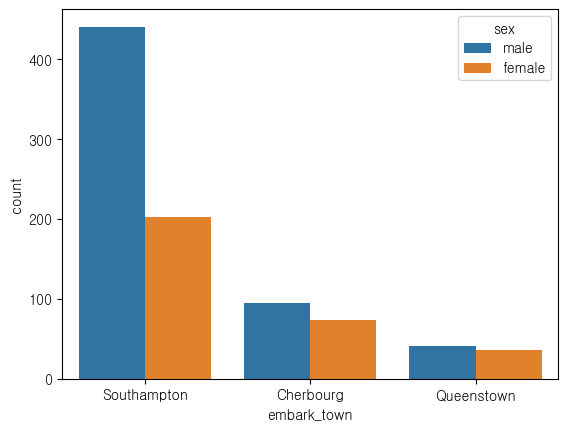

In [1005]:
# 2.1 여기에 답안 코드를 작성하세요 (첫번째, 두번째)

#    1. countplot 그래프에서 embark_town 분포를 확인시 Southampton 분포가 제일 크다 (O)
#    2. 탑승자의 성별 분포를 보면 모든 승선항구에서 'female'의 수가 'male'의 수보다 작다 (O)
#    3. 승선항구의 모든 도시에서 'female'의 비율이 절반 이상이다 (x) => 남성의 비율이 절반 이상이다(O)

sns.countplot(data=df, x='embark_town', hue='sex')

print(df.groupby('embark_town')['sex'].value_counts(normalize=True).unstack()['male']) ; print()
print((df['sex']=='female').groupby(df['embark_town']).mean())

('Queenstown', 'First')

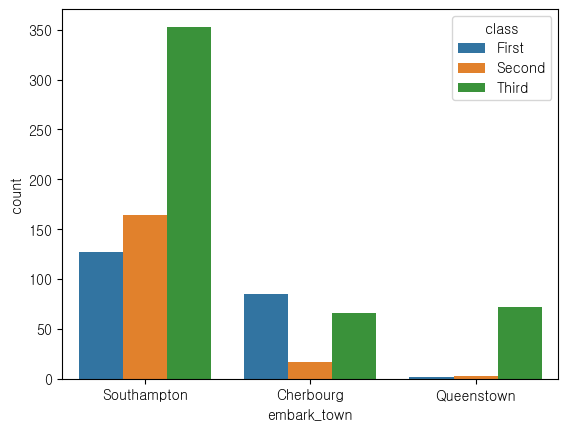

In [1006]:
# 2.2 여기에 답안 코드를 작성하세요 (세번째, 답안02)
#    4. 승선항구별 'class'의 탑승인원이 가장 적은 경우는 'Queenstown'의 'First' 이다 (o)

sns.countplot(df, x='embark_town', hue='class')

df.groupby('embark_town')['class'].value_counts().reset_index()
df.groupby('embark_town', as_index=False)['class'].value_counts().reset_index()

df.groupby('embark_town')['class'].value_counts().idxmin()
df.groupby('embark_town')['class'].value_counts().sort_values().index[0]

- 수치형 컬럼들에서 'fare' 컬럼을 제외한 후 변수 num_cols에 저장하세요. (통상 주어짐, ex: 아래코드를 실행하시오)

In [1008]:
# 수치형 컬럼에서 'fare'를 제외한 후 변수 num_cols에 저장하시오(통상 주어짐)

num_cols = df.select_dtypes(include='number').columns.drop('fare')
print(num_cols)

Index(['survived', 'pclass', 'age', 'sibsp', 'parch'], dtype='object')


#### 3. 위의 변수를 활용하여 상관관계를 나타내는 코드를 작성하고, 히트맵을 그리시오
- seaborn을 활용하여 히트맵을 그리고, 상관계수는 소숫점 둘째자리까지 표시되도록 작성하세요
- 상관계수 컬러맵의 색상은 coolwarm, 최솟값은 -1, 최댓값은 1로 설정하세요
- 'age' 컬럼과의 상관계수가 가장 큰 컬럼을 '답안02' 변수에 저장하세요(예. 답안03 = 'result')

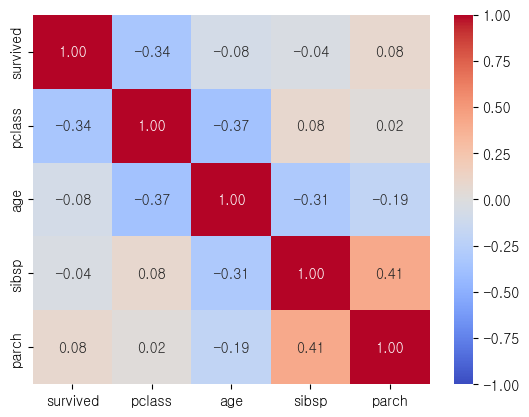

In [1010]:
# 4. 여기에 답안코드를 작성하세요.

sns.heatmap(df[num_cols].corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
답안03='pclass'

#### 4. 선실등급(class)별 나이(age)의 분포를 성별(sex)에 따른 분포를 보여주는 boxplot 으로 작성하시오.
- seaborn을 활용하고, x 축에는 class, y축에는 age를 표시하세요
- 출력된 그래프를 보고 해석한 것으로 옳지 않은 선택지를 골라 '답안04' 변수에 저장하세요(예. 답안04 = 4)
  1. First class 의 범위가 가장 크다
  2. 모든 class 에서 이상치가 존재하는 것은 아니다
  3. 모든 class 에서 남성이 여성보다 최댓값이 높다
  4. 모든 class 에서 남성이 여성보다 평균이 높다

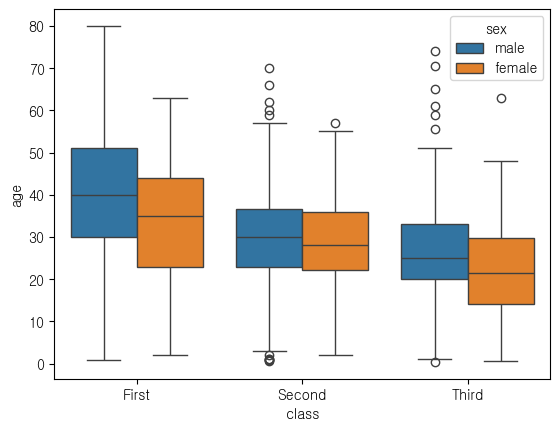

In [1012]:
# 4. 여기에 답안코드를 작성하세요.

sns.boxplot(df, x='class', y='age', hue='sex')
답안04=4

#### 5. groupby를 사용하여 생존한 사람들 중, deck 별로 성인남성(adult_male)의 비율이 가장 높은 deck를 구하고, seaborn의 barplot으로 표시하시오.
예. 답안05 = 'H'

A



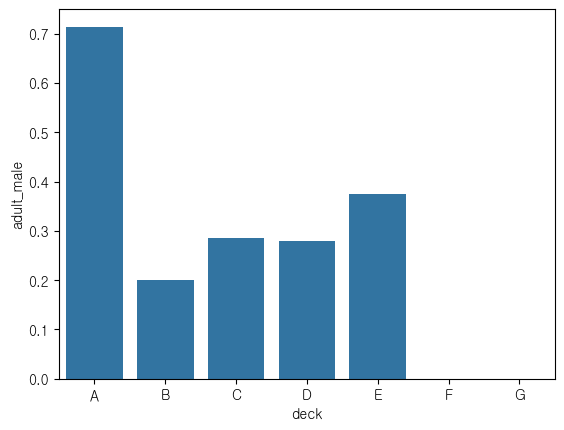

In [1014]:
# 5. 여기에 답안코드를 작성하세요.

print(df[df['survived']==1].groupby('deck')['adult_male'].mean().sort_values(ascending=False).idxmax()) ; print()
sns.barplot(df[df['survived']==1].groupby('deck')['adult_male'].mean()) ; plt.show()
답안05='A'

#### 6. 결측치가 있는 컬럼들만 추려서 컬럼명과 결측치의 수를 null_true 변수에 저장하시오
####  null_true 변수를 사용하여 결측치가 있는 컬럼명을 null_cols 변수에 리스트 형태로 저장하시오

In [1016]:
# 6. 여기에 답안코드를 작성하세요.

null_true = df.isnull().sum() [df.isnull().sum() > 0]
null_cols = null_true.index.to_list()
print(null_cols)

['age', 'embarked', 'deck', 'embark_town']


* 아래 코드를 실행하시오

In [1018]:
# embark_cols = df_temp.columns[df_temp.columns.str.contains('embark')]

#### 7. 모델링 성능을 제대로 얻기 위해서 결측치 처리는 필수입니다. 아래 가이드를 따라 결측치 처리하세요.
- 1. 대상 데이터프레임 : df를 복사하여 df_temp 로 저장한 후 각 컬럼의 결측치 비율을 확인하세요.
- 2. 결측치가 50% ~ 1% 이면 평균으로 대체하고, 50% 초과이면 삭제(inplace 사용)하세요.
- 3. 결측치가 해당 컬럼 데이터의 1% 미만은 'embark_cols' 변수(컬럼명에 'embark' 단어를 포함)와 for문을 사용하여 최빈값으로 대체하세요.
- 4. 'embark_town' 은 'embarked'와 동일한 데이터로 확인되었으므로, 'embark_town' 컬럼을 삭제하시오
- 5. 전처리 반영된 결과를 데이터프레임 변수명 df_na 에 저장하세요.

In [1020]:
df_temp = df.copy()
print(df_temp.shape) ; print()
print(df_temp.isnull().mean().sort_values(ascending=False)[:4])

# 50% ~ 1% 이면 평균으로 대체
df_temp['age'] = df_temp['age'].fillna(df_temp['age'].mean())

# 50% 초과 삭제
df_temp.drop(columns='deck', inplace=True)

# for 문 사용 (시험에서는 emabrk_cols 변수 보통 주어짐)
embark_cols = df_temp.columns[df_temp.columns.str.contains('embark')]
print(embark_cols) ; print()
for col in embark_cols:
    df_temp[col] = df_temp[col].fillna(df_temp[col].mode()[0] )
    
# embark_town 삭제
df_na = df_temp.drop(columns=['embark_town'])
print(df_na.shape)

(891, 15)

deck           0.772166
age            0.198653
embarked       0.002245
embark_town    0.002245
dtype: float64
Index(['embarked', 'embark_town'], dtype='object')

(891, 13)


#### 8. 모델링 성능을 제대로 얻기 위해서 불필요한 변수는 삭제해야 합니다. 아래 가이드를 따라 불필요 데이터를 삭제 처리하세요.
- 대상 데이터프레임 : df_na
- 'class', 'who', 'adult_male', 'alive', 'alone' 5개 컬럼을 삭제하세요.
- 전처리 반영된 결과를 새로운 데이터프레임 변수명 df_del 에 저장하세요.

In [1022]:
# 8. 여기에 답안코드를 작성하세요.

df_del = df_na.drop(columns=['class', 'who', 'adult_male', 'alive', 'alone' ])
print(df_del.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked'],
      dtype='object')


#### 9. 원-핫 인코딩(One-hot encoding)은 범주형 변수를 1과 0의 이진형 벡터로 변환하기 위하여 사용하는 방법입니다.
#### 원-핫 인코딩으로 아래 조건에 해당하는 컬럼 데이터를 변환하세요.
- 대상 데이터프레임 : df_del
- 원-핫 인코딩 대상 : object 타입의 전체 컬럼, 변수명은 obj_cols
- 활용 함수: Pandas의 get_dummies
- 첫번째 가변수: 삭제 처리
- 데이터 타입: 정수
- 해당 전처리가 반영된 결과를 데이터프레임 변수 df_preset에 저장해 주세요.

In [1024]:
# 9. 여기에 답안코드를 작성하세요.

obj_cols = df_del.select_dtypes(include='object').columns
df_preset = pd.get_dummies(data=df_del, columns=obj_cols, drop_first=True, dtype=int)
df_preset

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.000000,1,0,7.2500,1,0,1
1,1,1,38.000000,1,0,71.2833,0,0,0
2,1,3,26.000000,0,0,7.9250,0,0,1
3,1,1,35.000000,1,0,53.1000,0,0,1
4,0,3,35.000000,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,1,0,1
887,1,1,19.000000,0,0,30.0000,0,0,1
888,0,3,29.699118,1,2,23.4500,0,0,1
889,1,1,26.000000,0,0,30.0000,1,0,0


#### 10. 훈련과 검증 각각에 사용할 데이터셋을 분리하려고 합니다.
#### fare(요금) 컬럼을 label값 y로, 나머지 컬럼을 feature값 X로 할당한 후 훈련데이터셋과 검증데이터셋으로 분리하세요.
#### 추가로, 가이드 따라서 훈련데이터셋과 검증데이터셋에 스케일링을 수행하세요.
- 대상 데이터프레임: df_preset
-  훈련과 검증 데이터셋 분리
   -  훈련 데이터셋 label : y_train, 훈련 데이터셋 Feature: X_train
   -  검증 데이터셋 label : y_valid, 검증 데이터셋 Feature: X_valid
   -  훈련 데이터셋과 검증데이터셋 비율은 80:20
   -  random_state : 42
   -  Scikit-learn의 train_test_split 함수를 활용하세요.
-  RobustScaler 스케일링 수행
   -  sklearn.preprocessing의 RobustScaler 함수 사용
   -  훈련데이터셋의 Feature는 RobustScaler의 fit_transform 함수를 활용하여 X_train 변수로 할당
   -  검증데이터셋의 Feature는 RobustScaler의 transform 함수를 활용하여 X_valid 변수로 할당

In [1026]:
# 10. 여기에 답안코드를 작성하세요.

print(df_preset.shape) # (819 ,9)
y = df_preset['fare']
X = df_preset.drop(columns='fare')
print(X.shape, y.shape) # (891, 8) (891,)

from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape, X_valid.shape, y_valid.shape)

from sklearn.preprocessing import RobustScaler #, MinMaxScaler, StandardScaler
rs = RobustScaler()
X_train = rs.fit_transform(X_train)
X_valid = rs.transform(X_valid)

print(X_train.shape, X_valid.shape)

(891, 9)
(891, 8) (891,)
(712, 8) (712,) (179, 8) (179,)
(712, 8) (179, 8)


#### 11. fare(요금)을 예측하는 머신러닝 모델을 만들려고 합니다.
#### 의사결정나무(decision tree)와 랜덤포레스트(RandomForest)는 여러 가지 규칙을 순차적으로 적용하면서
#### 독립 변수 공간을 분할하는 모형으로 분류(classification)와 회귀 분석(regression)에 모두 사용될 수 있습니다.
#### 아래 가이드에 따라 의사결정나무(decision tree)와 랜덤포레스트(RandomForest) 모델 만들고 학습을 진행하세요.
- 의사결정나무(decision tree)
  - 트리의 최대 깊이 : 5로 설정
  - 노드를 분할하기 위한 최소한의 샘플 데이터수(min_samples_split) : 3로 설정
  - random_state : 120로 설정
  - 의사결정나무(decision tree) 모델을 dt 변수에 저장해 주세요.
- 랜덤포레스트(RandomForest)
  - 트리의 최대 깊이 : 5로 설정
  - 노드를 분할하기 위한 최소한의 샘플 데이터수(min_samples_split) : 3로 설정
  - random_state : 120로 설정
  - 랜덤포레스트(RandomForest) 모델을 rf 변수에 저장해 주세요.
- xgboost
  - 트리의 최대 깊이 : 5로 설정
  - 노드를 분할하기 위한 최소한의 샘플 데이터수(min_samples_split) : 3로 설정
  - learning_rate: 0.05로 설정
  - random_state : 120로 설정
  - xgb 모델을 xgb 변수에 저장해 주세요.
- lightGBM
  - 트리의 최대 깊이 : 5로 설정
  - 노드를 분할하기 위한 최소한의 샘플 데이터수(min_child_samples) : 3로 설정
  - learning_rate: 0.05로 설정
  - random_state : 120로 설정
  - lgbm 모델을 xgb 변수에 저장해 주세요.
- 위의 4개의 모델에 대해 fit을 활용해 모델을 학습해 주세요. 학습 시 훈련데이터 셋을 활용해 주세요.

In [1028]:
# 11. 여기에 답안코드를 작성하세요.

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

dt = DecisionTreeRegressor(max_depth=5, min_samples_split=3, random_state=120)
rf = RandomForestRegressor(max_depth=5, min_samples_split=3, random_state=120)
xgb = XGBRegressor(max_depth=5, min_samples_split=3, learning_rate=0.05, random_state=120)
lgbm = LGBMRegressor(max_depth=5, min_child_samples=3, learning_rate=0.05, random_state=120)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 84
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] Start training from score 32.586276
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

LGBMRegressor(learning_rate=0.05, max_depth=5, min_child_samples=3,
              random_state=120)

#### 12. 위 모델들의 성능을 평가하려고 합니다.
#### 아래 가이드에 따라 예측 결과의 rmse(Root Mean Squared Error)를 구하고 평가하세요.
- 성능 평가는 검증 데이터셋을 활용하세요.
- 11번 문제에서 만든 의사결정나무(decision tree) 모델로 y값을 예측(predict)하여 y_pred_dt에 저장하세요.
- 검증 정답(y_valid)과 예측값(y_pred_dt)의 rmse를 구하고 dt_rmse 변수에 저장하세요.
- 11번 문제에서 만든 랜덤포레스트(RandomForest) 모델로 y값을 예측(predict)하여 y_pred_rf에 저장하세요.
- 검증 정답(y_valid)과 예측값(y_pred_rf)의 rmse를 구하고 rf_rmse 변수에 저장하세요.
- 11번 문제에서 만든 xgboost 모델로 y값을 예측(predict)하여 y_pred_xgb에 저장하세요.
- 검증 정답(y_valid)과 예측값(y_pred_xgb)의 rmse를 구하고 xgb_rmse 변수에 저장하세요.
- 11번 문제에서 만든 lightgbm 모델로 y값을 예측(predict)하여 y_pred_lgbm에 저장하세요.
- 검증 정답(y_valid)과 예측값(y_pred_lgbm)의 rmse를 구하고 lgbm_rmse 변수에 저장하세요.
- 4개의 모델에 대한 rmse 성능평가 결과을 확인하여 성능좋은 모델 이름을 '답안12' 변수에 저장하세요.
  -  예) 답안12 = 'randomforest'

In [1030]:
# 12. 여기에 답안코드를 작성하세요.

y_pred_dt = dt.predict(X_valid)
y_pred_rf = rf.predict(X_valid)
y_pred_xgb = xgb.predict(X_valid)
y_pred_lgbm = lgbm.predict(X_valid)

from sklearn.metrics import root_mean_squared_error #, mean_absolute_error, mean_absolute_percentage_error, r2_score, roc_auc_score
dt_rmse = root_mean_squared_error(y_valid, y_pred_dt)
rf_rmse = root_mean_squared_error(y_valid, y_pred_rf)
xgb_rmse = root_mean_squared_error(y_valid, y_pred_xgb)
lgbm_rmse = root_mean_squared_error(y_valid, y_pred_lgbm)

# 답안12= 'randomforest'

print(pd.Series({'dt': dt_rmse, 'rf': rf_rmse, 'xgb': xgb_rmse, 'lgbm': lgbm_rmse }).sort_values()) ; print()
print(pd.Series({'dt': dt_rmse, 'rf': rf_rmse, 'xgb': xgb_rmse, 'lgbm': lgbm_rmse }).idxmin())

답안12= 'randomforest'

rf      32.240962
lgbm    38.072822
dt      38.910748
xgb     39.946094
dtype: float64

rf


#### 12_1 가장 성능이 좋은 알고리즘의 변수 중요도를 출력하고, 가장 큰 변수를 '답안12_1' 변수에 저장하세요.

In [1032]:
pd.Series(rf.feature_importances_ , X.columns).sort_values(ascending=False).index[0]
pd.Series(rf.feature_importances_ , X.columns).idxmax()

pd.DataFrame({'feature':X.columns, 'importance':rf.feature_importances_}).sort_values('importance', ascending=False)
답안12_1='pclass'

#### 다음 문항을 풀기 전에 아래 코드를 실행하세요.

In [1034]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(1)

#### 13. 운임(fare)을 예측하는 딥러닝 모델을 만들려고 합니다.
#### 아래 토폴로지 그림과 가이드에 따라 모델링하고 학습을 진행하는 코드를 작성하세요.
- Tensorflow framework를 사용하고 하단의 토폴로지 그림과 동일한 딥러닝 모델을 구현하세요.
- 히든레이어(hidden layer)이 activation 함수는 'selu'를 사용하고, 마지막 아웃풋 레이어의 activation 함수는 'linear'를 사용하세요.
- EarylyStopping 콜백으로 9번 epoch 동안 모니터링 지표(val_loss)가 향상되지 않을 때 훈련을 중지하도록 설정하고 estop 변수에 저장하세요.
- ModelCheckpoint 는 가장 성능이 좋은 모델명을 'best_model.kears'로 저장하세요. 변수는 cpoint로 저장하세요
- optimizer는 adam, metrics는 mse, loss는 mean_squared_error로 설정하여 모델 컴파일을 설정하세요.
  - batch_size: 128
  - epoch: 50 
- 안내된 내용외 별도의 파라미터를 입력하지 마시기 바랍니다.

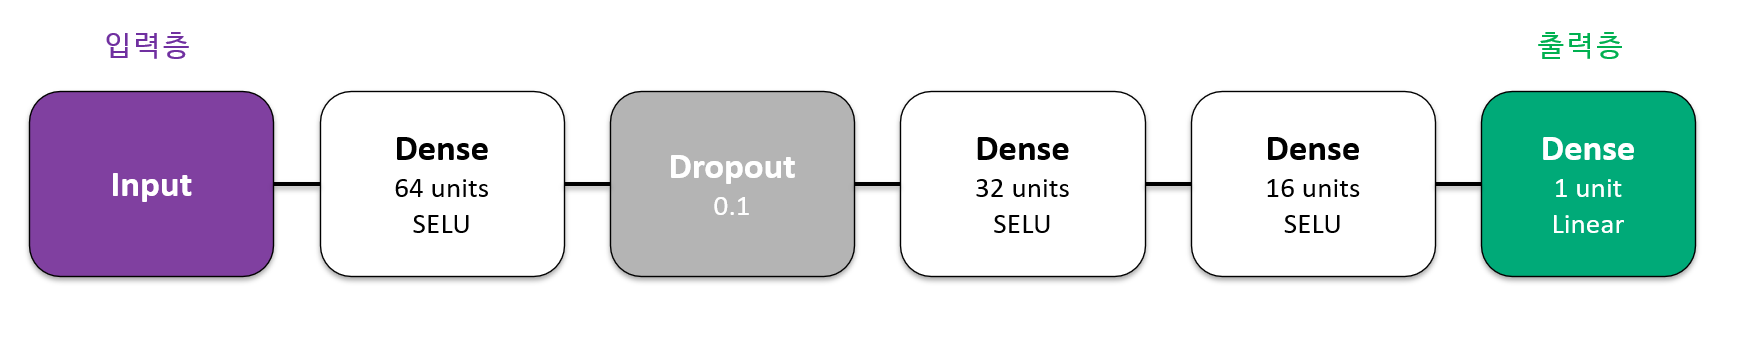

In [1037]:
model = Sequential([
    Dense(units=64, activation='selu'),  #, input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(32, 'selu'),
    Dense(16, 'selu'),
    Dense(1, 'linear')
])

estop = EarlyStopping(patience=9, monitor='val_loss', verbose=1)
cpoint = ModelCheckpoint('best_model.keras', save_best_only=True)

model.compile(optimizer='adam', metrics=['mse'], loss='mean_squared_error' )

history = model.fit( X_train, y_train, epochs=50, batch_size=128,
          validation_data=(X_valid, y_valid),
          callbacks=[estop, cpoint] )


Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 3384.9690 - mse: 3384.9690 - val_loss: 2439.8459 - val_mse: 2439.8459
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3292.5828 - mse: 3292.5828 - val_loss: 2364.8325 - val_mse: 2364.8325
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3213.6946 - mse: 3213.6946 - val_loss: 2298.4426 - val_mse: 2298.4424
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3141.9470 - mse: 3141.9470 - val_loss: 2232.7085 - val_mse: 2232.7085
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3071.3601 - mse: 3071.3601 - val_loss: 2164.1375 - val_mse: 2164.1375
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2998.0823 - mse: 2998.0823 - val_loss: 2092.1040 - val_mse: 2092.1040
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2919.6904 - mse: 2919.6904 - val_loss: 2016.7491 - val_mse: 2016.7491
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2838.8162 - mse: 2838.8162 - val_loss: 1937.6273 - val

#### 14. 위 딥러닝 모델의 성능을 평가하려고 합니다.
#### Matplotlib 라이브러리 활용해서 학습 mse와 검증 mse를 그래프로 표시하세요.
- 1개의 그래프에 학습 mse과 검증 mse 2가지를 모두 표시하세요.
- 위 2가지 각각의 범례를 'mse', 'val_mse'로 표시하세요.
- 그래프의 타이틀은 'Model MSE'로 표시하세요.
- X축에는 'Epochs'라고 표시하고 Y축에는 'MSE'라고 표시하세요.

In [1039]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                     │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,605 (37.52 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,404 (25.02 KB)

In [1040]:
model.history.history.keys()
pd.DataFrame(model.history.history)

,loss,mse,val_loss,val_mse
0,3767.947021,3767.947021,2439.845947,2439.845947
1,3677.029785,3677.029785,2364.832520,2364.832520
2,3600.597168,3600.597168,2298.442627,2298.442383
3,3529.676025,3529.676025,2232.708496,2232.708496
4,3459.419922,3459.419922,2164.137451,2164.137451
5,3383.640137,3383.640137,2092.104004,2092.104004
6,3306.097656,3306.097656,2016.749146,2016.749146
7,3224.725830,3224.725830,1937.627319,1937.627319
8,3135.149658,3135.149658,1854.055176,1854.055176
9,3038.918213,3038.918213,1765.280029,1765.280029


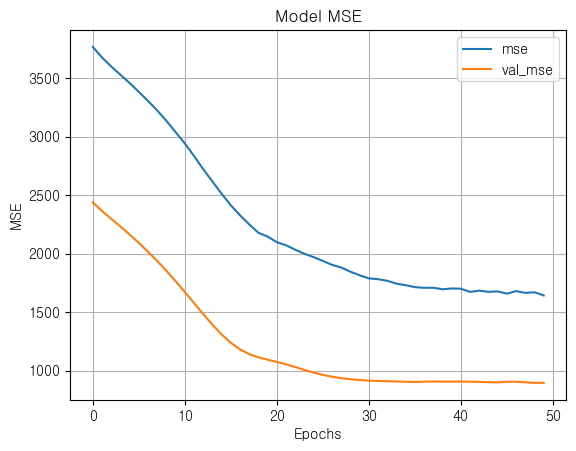

In [1041]:
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])
plt.legend(['mse', 'val_mse'])
plt.title('Model MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.grid()

#### 15. 베스트 모델을 불러와 아래 데이터가 입력시 출력값을 기재하시오

In [1043]:
import numpy as np
simul_data = np.array([[0.2, 0.01, 1.3, 0.8, 0.1, -0.05, 0.01, -1.05]])

In [1044]:
model = load_model('best_model.keras')
model.predict(simul_data)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


array([[20.261799]], dtype=float32)

In [1045]:
# End 